## 0. 설정

In [1]:
<< mTensor`

In [2]:
$PreRead = 
  ReplaceAll[#, 
    expr_String :> StringReplace[expr,
    "TMP" -> "mTensor`Private"]] &;

In [3]:
DefineKind[Alphabet["Greek"], Greek];
DefineKind[ToUpperCase /@ Alphabet[], Capital];
DefineKind["b" <> # & /@ Alphabet[], Bar];
DefineKind["d" <> # & /@ Alphabet[], Dot];
DefineKind["h" <> # & /@ Alphabet[], Hat];

## 1. Objects

Object는 `IndexedObject`와 `ScalarFunction`으로 나뉜다. 그리고 `IndexedObject`는 Operator와 Operand(Tensor, Form 등)로 나뉜다.

Object와 관련된 함수는 옵션으로 그것의 이름이 만족해야 할 질의함수 리스트인 `HeadQs`를 가질 수 있다. 이 옵션이 존재하는 함수는 그 질의함수들을 모두 만족하는 것들에 대해서만 작용한다. 질의함수는 이름, 즉 `Head`를 인자로 하는 함수이어야 한다. 예를 들면, `T[la,lb]`에서 질의함수 `f`의 결과값은 `f[T]`이고, `CD[la,T[lb,lc]]`에서는 `f[T]`의 값이 아니고 `f[CD]`의 값이다. 이것은 `CD[la,T[lb,lc]]`의 `Head`가 `CD`이기 때문이다. 이 옵션을 사용하면 임의의 Object를 특정한 질의함수만을 만족하는 Object들로 분류할 수 있고, 연산도 그러한 종류에만 작용시킬 수 있다.

`HeadQs`의 디폴트 옵션은 `IndexedObjectQ`이다. 따라서 보통의 연산에서 `ScalarFunction`들은 제외된다. `ScalarFunction`들을 포함한 모든 Object에 연산을 적용하려면 `HeadQs` 옵션에 `ObjectQ`를 사용하면 된다.

### 1.1 RemoveObject

프로그램 사용 중 정의한 Object의 이름을 프로그램에서 제거한다. 인자는 이름이나 이름 리스트이다. 정의되지 않은 이름에는 아무런 변화가 없다. 프로그램에서 미리 정의된 Object의 이름은 제거할 수 없다.

### 1.2 ObjectQ

인자로 주어진 이름이 Tensor, Operator 등의 `IndexedObject`이거나 `ScalarFunction`이면 참값을 돌려주는 질의함수이다.

### 1.3 IndexedObjectQ

인자로 주어진 이름이 Tensor, Operator 등이면 참값을 돌려주는 질의함수이다.

### 1.4 ScalarFunctionQ

인자로 주어진 이름이 `ScalarFunction`이면 참값을 돌려주는 질의함수이다.

In [8]:
ScalarFunctionQ /@ {Tscalar, Power, Log, CD}

{True, True, True, False}

### 1.5 IndexedOperatorQ

인자로 주어진 이름이 Operator이면 참값을 돌려주는 질의함수이다.

### 1.6 IndexedOperandQ

인자로 주어진 이름이 Operand이면 참값을 돌려주는 질의함수이다.

### 1.7 IndexedTensorQ

인자로 주어진 이름이 Tensor이면 참값을 돌려주는 질의함수이다.

## 2. Operands

### 2.1 stringToImag

In [9]:
TMP`stringToImag[" abc "]

Imag[1, 2, 3]

In [10]:
TMP`stringToImag[" -bac"]

-Imag[2, 1, 3]

In [11]:
TMP`stringToImag["  +  cba"]

Imag[3, 2, 1]

In [12]:
TMP`stringToImag[" aba"]

`1` is not a valid `2`.:  aba is not a valid perm.

In [13]:
TMP`stringToImag["- abc"]

`1` is not a valid `2`.: - abc is not a valid signed perm.

### 2.2 toRankAndGenSet

대칭 문자열은 Latin 계열의 문자인 'a'에서 'z'까지의 문자로 이루어진 문자열이고, 대칭이면 '+', 반대칭이면 '-'가 첫 번째 문자이다.

함수 `toRankAndGenSet`은 대칭 문자열을 `{rank, symmetry}`로 변환한다:

In [14]:
TMP`toRankAndGenSet[""]

{0, GenSet[]}

In [15]:
TMP`toRankAndGenSet["ab"]

{2, GenSet[]}

In [16]:
TMP`toRankAndGenSet["-bac-acb"]

{3, GenSet[{Cycles[{{1, 2}}], -1}, {Cycles[{{2, 3}}], -1}]}

대칭 문자열 대신에 rank의 값을 직접 입력할 수 있다:

In [17]:
TMP`toRankAndGenSet["10"]

{10, Nonsymmetric}

대칭 문자열 대신에 rank의 값을 입력하면서 대칭 또는 반대칭을 지정할 수 있다:

In [18]:
TMP`toRankAndGenSet["10+"]

{10, Symmetric}

In [19]:
TMP`toRankAndGenSet["10-"]

{10, Antisymmetric}

임의의 rank를 갖는 경우:

In [20]:
TMP`toRankAndGenSet["*"]

{-1, Nonsymmetric}

In [21]:
TMP`toRankAndGenSet["*+"]

{-1, Symmetric}

In [22]:
TMP`toRankAndGenSet["*-"]

{-1, Antisymmetric}

#### Check

대칭 문자열에 오류가 있으면 `{-1, "Error"}`를 돌려준다:

In [23]:
TMP`stringToImag["-abc"]

`1` is not a valid `2`.: -abc is not a valid signed perm.

In [24]:
TMP`toRankAndGenSet["-abc"]

`1` is not a valid `2`.: -abc is not a valid signed perm.

{-1, Error}

In [25]:
TMP`toRankAndGenSet["ab+abc"]

`1` is not a valid `2`.: ab+abc is not a valid perm; it has inconsistent rank.

{-1, Error}

In [26]:
TMP`toRankAndGenSet["abc-ba"]

`1` is not a valid `2`.: abc-ba is not a valid perm; it has inconsistent rank.

{-1, Error}

In [27]:
TMP`toRankAndGenSet["-bac+acb"]

`1` is not a valid `2`.: -bac+acb is not a valid perm; it has inconsistent weights.

{-1, Error}

In [28]:
TMP`toRankAndGenSet["acb-bac"]

`1` is not a valid `2`.: acb-bac is not a valid perm; it has inconsistent weights.

{-1, Error}

In [29]:
TMP`toRankAndGenSet["bac-bac"]

`1` is not a valid `2`.: bac-bac is not a valid perm; it has inconsistent weights.

{-1, Error}

In [30]:
TMP`stringToImag["abc"]

Imag[1, 2, 3]

In [31]:
TMP`stringToImag["bcf"]  (* "bcf" is ordered: 'b' < 'c' < 'f' *)

Imag[1, 2, 3]

In [32]:
TMP`toRankAndGenSet["abc+bcf"]  (* It's OK! *)

{3, GenSet[]}

In [33]:
TMP`stringToImag["aa"]  (* Use "ab" *)

`1` is not a valid `2`.: aa is not a valid perm.

In [34]:
TMP`toRankAndGenSet["aa"]

`1` is not a valid `2`.: +aa is not a valid perm.

{-1, Error}

In [35]:
TMP`stringToImag["-ab"]  (* Use "ab" *)

`1` is not a valid `2`.: -ab is not a valid signed perm.

In [36]:
TMP`toRankAndGenSet["-ab"]

`1` is not a valid `2`.: -ab is not a valid signed perm.

{-1, Error}

In [37]:
TMP`stringToImag["-cab"]  (* Use "cab" *)

`1` is not a valid `2`.: -cab is not a valid signed perm.

In [38]:
TMP`toRankAndGenSet["-cab"]

`1` is not a valid `2`.: -cab is not a valid signed perm.

{-1, Error}

In [39]:
TMP`stringToImag["ac"]  (* It's OK! *)

Imag[1, 2]

In [40]:
TMP`toRankAndGenSet["ac"]

{2, GenSet[]}

### 2.3 symToGenSet

In [41]:
TMP`symToGenSet["Antisymmetric", 3]

GenSet[{Cycles[{{1, 2}}], -1}, {Cycles[{{2, 3}}], -1}]

In [42]:
TMP`symToGenSet["Symmetric", 4]

GenSet[{Cycles[{{1, 2}}], 1}, {Cycles[{{2, 3}}], 1}, {Cycles[{{3, 4}}], 1}]

In [43]:
TMP`symToGenSet["Nonsymmetric", 5]

GenSet[]

In [44]:
TMP`symToGenSet[GenSet[], 3]

GenSet[]

### 2.4 Tdefine, defineOperand

새로운 `IndexedObject`를 정의한다. 인자로는 `IndexedObject`의 이름, 출력을 위한 문자열, 대칭 문자열, kind 리스트, Dnup 리스트, 옵션으로 디폴트가 `IndexedTensorQ`인 oType이 있다. `IndexedObject`의 rank는 입력한 대칭 문자열로부터 자동적으로 계산된다. `IndexedObject`의 이름과 대칭 문자열만이 인자로 있을 경우는 출력을 위한 문자열은 `IndexedObject`의 이름과 같다. 이 함수에 의해 정의된 텐서는 질의 함수 `IndexedTensorQ`를 만족한다.

#### 2.4.1 zero rank

In [45]:
Tdefine[s[]]; s[]

s[]

In [46]:
Tdefine[s, ""]; s[]

s[]

In [47]:
TMP`defineOperand[s, "s", "", {Latin}, {}]; s[]

s[]

In [49]:
Tdefine[scaf[], "f"]; scaf[]

scaf[]

In [50]:
Tdefine[scaf, "f", ""]; scaf[]

scaf[]

In [51]:
TMP`defineOperand[scaf, "f", "", {Latin}, {}]; scaf[]

scaf[]

In [52]:
Tdefine[lambda[], Greek]; lambda[]

lambda[]

In [53]:
Tdefine[lambda, "", Greek]; lambda[]

lambda[]

In [54]:
TMP`defineOperand[lambda, "lambda", "", {Greek}, {}]; lambda[]

lambda[]

In [55]:
Tdefine[Lambda[], "\[CapitalLambda]", Greek]; Lambda[]

Lambda[]

In [56]:
Tdefine[Lambda, "\[CapitalLambda]", "", Greek]; Lambda[]

Lambda[]

In [57]:
TMP`defineOperand[Lambda, "\[CapitalLambda]", "", {Greek}, {}];
Lambda[]

Lambda[]

In [59]:
TMP`defineOperand[scaA, "A", "", {Capital}, {}]; scaA[]

scaA[]

여러 개의 텐서들을 동시에 정의할 수 있다.

In [60]:
Tdefine[{u[], v[], w[]}]; {u[], v[], w[]}

{u[], v[], w[]}

In [61]:
Tdefine[{u, v, w}, ""]; {u[], v[], w[]}

{u[], v[], w[]}

#### 2.4.2 finite fixed-rank and no-symmetric, all the same shape

In [62]:
Tdefine[tens, 10]; tens[la, lb, lc, ld, lf, lg, lh, li, lj, lk]

tens[la, lb, lc, ld, lf, lg, lh, li, lj, lk]

In [63]:
TMP`defineOperand[tens, "tens", "10", {Latin}, {-1}];
tens[la, lb, lc, ld, lf, lg, lh, li, lj, lk]

tens[la, lb, lc, ld, lf, lg, lh, li, lj, lk]

In [65]:
Tdefine[tens, "T", 8]; tens[la, lb, lc, ld, lf, lg, lh, li]

tens[la, lb, lc, ld, lf, lg, lh, li]

In [66]:
TMP`defineOperand[tens, "T", "8", {Latin}, {-1}];
tens[la, lb, lc, ld, lf, lg, lh, li]

tens[la, lb, lc, ld, lf, lg, lh, li]

In [68]:
Tdefine[tens, 3, Capital]; tens[lA, lB, lC]

tens[lA, lB, lC]

같은 rank를 갖는 여러 개의 텐서들을 동시에 정의할 수 있다.

In [69]:
Tdefine[{u, v, w}, 1]; {u[la], v[lb], w[lc]}

{u[la], v[lb], w[lc]}

#### 2.4.3 finite fixed-rank and any symmetric, all the same shape

In [70]:
Tdefine[tens, "abcd"]; tens[la, lb, lc, ld]

tens[la, lb, lc, ld]

In [71]:
TMP`defineOperand[tens, "tens", "abcd", {Latin}, {-1}];
tens[la, lb, lc, ld]

tens[la, lb, lc, ld]

In [73]:
Tdefine[tens, "T", "abc"]; tens[la, lb, lc]

tens[la, lb, lc]

In [74]:
TMP`defineOperand[tens, "T", "abc", {Latin}, {-1}];
tens[la, lb, lc]

tens[la, lb, lc]

같은 permutation을 갖는 여러 개의 텐서들을 동시에 정의할 수 있다.

In [76]:
Tdefine[{u, v, w}, "-ba"]; {u[la, lb], v[la, lb], w[la, lb]}

{u[la, lb], v[la, lb], w[la, lb]}

#### 2.4.4 finite fixed-rank and totally symmetric or anti-symmetric, all the same shape

In [77]:
Tdefine[tens, "7+"]; tens[la, lb, lc, ld, lf, lg, lh]

tens[la, lb, lc, ld, lf, lg, lh]

In [78]:
TMP`defineOperand[tens, "tens", "7+", {Latin}, {-1}];
tens[la, lb, lc, ld, lf, lg, lh]

tens[la, lb, lc, ld, lf, lg, lh]

In [80]:
Tdefine[tens, "5-"]; tens[la, lb, lc, ld, lf]

tens[la, lb, lc, ld, lf]

In [81]:
TMP`defineOperand[tens, "tens", "5-", {Latin}, {-1}];
tens[la, lb, lc, ld, lf]

tens[la, lb, lc, ld, lf]

In [83]:
Tdefine[tens, "T", "5+"]; tens[la, lb, lc, ld, lf]

tens[la, lb, lc, ld, lf]

In [84]:
TMP`defineOperand[tens, "T", "5+", {Latin}, {-1}];
tens[la, lb, lc, ld, lf]

tens[la, lb, lc, ld, lf]

In [86]:
Tdefine[tens[lA], "T", "4-"]; tens[lA, lB, lC, lD]

tens[lA, lB, lC, lD]

In [87]:
TMP`defineOperand[tens, "T", "4-", {Capital}, {-1}];
tens[lA, lB, lC, lD]

tens[lA, lB, lC, lD]

같은 permutation을 갖는 여러 개의 텐서들을 동시에 정의할 수 있다.

In [89]:
Tdefine[{u, v, w}, "2-"]; {u[la, lb], v[la, lb], w[la, lb]}

{u[la, lb], v[la, lb], w[la, lb]}

#### 2.4.5 arbitrary-rank and no-symmetric, all the same shape

In [90]:
Tdefine[tens, "*"];
{tens[la], tens[la, lb], tens[la, lb, lc],
 tens[la, lb, lc, ld, lf, lg]}

{tens[la], tens[la, lb], tens[la, lb, lc], tens[la, lb, lc, ld, lf, lg]}

In [92]:
TMP`defineOperand[tens, "tens", "*", {Latin}, {-1}];
{tens[la], tens[la, lb], tens[la, lb, lc],
 tens[la, lb, lc, ld, lf, lg]}

{tens[la], tens[la, lb], tens[la, lb, lc], tens[la, lb, lc, ld, lf, lg]}

In [94]:
Tdefine[tens, "T", "*"];
{tens[la], tens[la, lb], tens[la, lb, lc],
 tens[la, lb, lc, ld, lf, lg]}

{tens[la], tens[la, lb], tens[la, lb, lc], tens[la, lb, lc, ld, lf, lg]}

In [96]:
TMP`defineOperand[tens, "T", "*", {Latin}, {-1}];
{tens[la], tens[la, lb], tens[la, lb, lc],
 tens[la, lb, lc, ld, lf, lg]}

{tens[la], tens[la, lb], tens[la, lb, lc], tens[la, lb, lc, ld, lf, lg]}

임의의 rank를 갖는 여러 개의 텐서들을 동시에 정의할 수 있다.

In [98]:
Tdefine[{u, v, w}, "*"]; {u[la], v[la, lb], w[la, lb, lc]}

{u[la], v[la, lb], w[la, lb, lc]}

#### 2.4.6 arbitrary-rank and totally-symmetric or anti-symmetric, all the same shape

In [99]:
Tdefine[tens, "*+"];
{tens[la], tens[la, lb], tens[la, lb, lc],
 tens[la, lb, lc, ld, lf, lg]}

{tens[la], tens[la, lb], tens[la, lb, lc], tens[la, lb, lc, ld, lf, lg]}

In [101]:
TMP`defineOperand[tens, "tens", "*+", {Latin}, {-1}];
{tens[la], tens[la, lb], tens[la, lb, lc],
 tens[la, lb, lc, ld, lf, lg]}

{tens[la], tens[la, lb], tens[la, lb, lc], tens[la, lb, lc, ld, lf, lg]}

In [103]:
Tdefine[tens, "T", "*-"];
{tens[la], tens[la, lb], tens[la, lb, lc],
 tens[la, lb, lc, ld, lf, lg]}

{tens[la], tens[la, lb], tens[la, lb, lc], tens[la, lb, lc, ld, lf, lg]}

In [105]:
TMP`defineOperand[tens, "T", "*-", {Latin}, {-1}];
{tens[la], tens[la, lb], tens[la, lb, lc],
 tens[la, lb, lc, ld, lf, lg]}

{tens[la], tens[la, lb], tens[la, lb, lc], tens[la, lb, lc, ld, lf, lg]}

In [107]:
Tdefine[tens, "*-", Capital];
{tens[uA], tens[uA, uB], tens[uA, uB, uC],
 tens[uA, uB, uC, uD, uE]}

{tens[uA], tens[uA, uB], tens[uA, uB, uC], tens[uA, uB, uC, uD, uE]}

In [109]:
Tdefine[tens[uA], "*-"];
{tens[uA], tens[uA, uB], tens[uA, uB, uC],
 tens[uA, uB, uC, uD, uE]}

{tens[uA], tens[uA, uB], tens[uA, uB, uC], tens[uA, uB, uC, uD, uE]}

In [111]:
TMP`defineOperand[tens, "tens", "*-", {Capital}, {+1}];
{tens[uA], tens[uA, uB], tens[uA, uB, uC],
 tens[uA, uB, uC, uD, uE]}

{tens[uA], tens[uA, uB], tens[uA, uB, uC], tens[uA, uB, uC, uD, uE]}

In [113]:
Tdefine[tens[uA], "T", "*-"];
{tens[uA], tens[uA, uB], tens[uA, uB, uC],
 tens[uA, uB, uC, uD, uE]}

{tens[uA], tens[uA, uB], tens[uA, uB, uC], tens[uA, uB, uC, uD, uE]}

In [115]:
TMP`defineOperand[tens, "T", "*-", {Capital}, {+1}];
{tens[uA], tens[uA, uB], tens[uA, uB, uC],
 tens[uA, uB, uC, uD, uE]}

{tens[uA], tens[uA, uB], tens[uA, uB, uC], tens[uA, uB, uC, uD, uE]}

임의의 rank를 갖는 여러 개의 텐서들을 동시에 정의할 수 있다.

In [117]:
Tdefine[{u, v, w}, "*+"]; {u[la], v[la, lb], w[la, lb, lc]}

{u[la], v[la, lb], w[la, lb, lc]}

#### 2.4.7 finite fixed-rank and no-symmetric, various shapes

In [118]:
Tdefine[tens[la, lb]]; tens[la, lb]

tens[la, lb]

In [119]:
TMP`defineOperand[tens, "tens", "ab", {Latin}, {-1}];
tens[la, lb]

tens[la, lb]

#### 2.4.8 finite fixed-rank and any symmetric, various shapes

In [121]:
Tdefine[tens[la, lb], "ab"]; tens[la, lb]

tens[la, lb]

In [122]:
TMP`defineOperand[tens, "tens", "ab", {Latin}, {-1}];
tens[la, lb]

tens[la, lb]

In [124]:
Tdefine[tens[la, lb], "T", "-ba"]; tens[la, lb]

tens[la, lb]

In [125]:
TMP`defineOperand[tens, "T", "-ba", {Latin}, {-1}];
tens[la, lb]

tens[la, lb]

#### 2.4.9 Usage

In [127]:
Tdefine[R[la, lb], "ba"]; R[la, lb]

R[la, lb]

In [128]:
TMP`defineOperand[R, "R", "ba", {Latin}, {-1}]; R[la, lb]

R[la, lb]

출력을 위한 문자열은 출력할 때만 사용된다.

In [129]:
Tdefine[affineG[la, lb, uc], "\[CapitalGamma]", "bac"];
affineG[lb, la, uc]

affineG[lb, la, uc]

In [131]:
TMP`defineOperand[affineG, "\[CapitalGamma]",
                   "bac", {Latin}, {-1, -1, 1}];
affineG[lb, la, uc]

affineG[lb, la, uc]

대칭 문자열에 반대칭이 있을 경우

In [133]:
Tdefine[F[la, lb], "-ba"];
{F[la, ub], F[-1, 1], F[-1, -1], F[la, ua]}

{F[la, ub], F[-1, 1], F[-1, -1], F[la, ua]}

In [135]:
TMP`defineOperand[F, "F", "-ba", {Latin}, {-1}];
{F[la, ub], F[-1, 1], F[-1, -1], F[la, ua]}

{F[la, ub], F[-1, 1], F[-1, -1], F[la, ua]}

In [137]:
Tdefine[cuvR[la, lb, lc, ud], "R", "-bacd"]

In [138]:
TMP`defineOperand[cuvR, "R", "-bacd", {Latin}, {-1, -1, -1, +1}]

In [139]:
cuvR[la, lb, lc, ud]

cuvR[la, lb, lc, ud]

Yang-Mills 게이지장 모양의 텐서:

In [140]:
Tdefine[F[l\[Mu], l\[Nu], ua], "-bac"]; F[l\[Mu], l\[Nu], ua]

F[lμ, lν, ua]

In [141]:
TMP`defineOperand[F, "F", "-bac",
                   {Greek, Greek, Latin}, {-1, -1, +1}];
F[l\[Mu], l\[Nu], ua]

F[lμ, lν, ua]

In [143]:
Tdefine[F[l\[Mu], l\[Nu], ua], "\[ScriptCapitalF]", "-bac"];
F[l\[Mu], l\[Nu], ua]

F[lμ, lν, ua]

In [145]:
TMP`defineOperand[F, "\[ScriptCapitalF]", "-bac",
                   {Greek, Greek, Latin}, {-1, -1, +1}];
F[l\[Mu], l\[Nu], ua]

F[lμ, lν, ua]

Permutation을 직접 입력하지 않고 rank에 해당하는 숫자를 문자열 형태로 입력할 수 있다:

In [147]:
Tdefine[T, 10]  (* rank == 10 and no symmetries *)

In [148]:
TMP`defineOperand[T, "T", "10", {Latin}, {-1}]

In [149]:
Tdefine[T, "10+"]  (* rank == 10 and totally symmetric *)

In [150]:
TMP`defineOperand[T, "T", "10+", {Latin}, {-1}]  

In [151]:
Tdefine[T, "10-"]  (* rank == 10 and totally anti-symmetric *)

In [152]:
TMP`defineOperand[T, "T", "10-", {Latin}, {-1}]

임의의 rank를 갖는 텐서를 정의할 수 있다:

In [153]:
Tdefine[T, "*"]; {T[la], T[la, ub], T[la, lb, lc, ld]}

{T[la], T[la, ub], T[la, lb, lc, ld]}

In [154]:
TMP`defineOperand[T, "T", "*", {Latin}, {-1}];
{T[la], T[la, ub], T[la, lb, lc, ld]}

{T[la], T[la, ub], T[la, lb, lc, ld]}

In [156]:
Tdefine[S, "*+"]; {S[la], S[la, ub], S[ld, la, lb, lc]}

{S[la], S[la, ub], S[ld, la, lb, lc]}

In [157]:
TMP`defineOperand[S, "S", "*+", {Latin}, {-1}];
{S[la], S[la, ub], S[ld, la, lb, lc]}

{S[la], S[la, ub], S[ld, la, lb, lc]}

In [159]:
Tdefine[Eps, "\[Epsilon]", "*-"];
{Eps[la, lb], Eps[ld, la, lb, lc]}

{Eps[la, lb], Eps[ld, la, lb, lc]}

In [161]:
TMP`defineOperand[Eps, "\[Epsilon]", "*-", {Latin}, {-1}];
{Eps[la, lb], Eps[ld, la, lb, lc]}

{Eps[la, lb], Eps[ld, la, lb, lc]}

모든 인덱스들이 동일한 Shape라면 한 개의 Shape만을 입력한다.

In [163]:
Tdefine[Eps[l\[Mu]], 3]; Eps[l\[Mu], l\[Nu], l\[Rho]]

Eps[lμ, lν, lρ]

In [164]:
TMP`defineOperand[Eps, "Eps", "3", {Greek}, {-1}];
Eps[l\[Mu], l\[Nu], l\[Rho]]

Eps[lμ, lν, lρ]

임의의 rank를 갖는 텐서는 모든 인덱스가 같은 Shape를 갖는다고 가정한다.

In [166]:
Tdefine[Eps[u\[Mu]], "\[Epsilon]", "*-"];
{Eps[u\[Mu], u\[Nu]], Eps[u\[Mu], u\[Nu], u\[Rho], u\[Sigma]]}

{Eps[uμ, uν], Eps[uμ, uν, uρ, uσ]}

In [168]:
TMP`defineOperand[Eps, "\[Epsilon]", "*-", {Greek}, {1}];
{Eps[u\[Mu], u\[Nu]], Eps[u\[Mu], u\[Nu], u\[Rho], u\[Sigma]]}

{Eps[uμ, uν], Eps[uμ, uν, uρ, uσ]}

#### 2.4.10 Pretty printing indices

In [170]:
Tdefine[R[la, lb], "ba"]; R[la, ub]

R[la, ub]

In [171]:
TMP`defineOperand[R, "R", "ba", {Latin}, {-1}]; R[la, ub]

R[la, ub]

In [173]:
R[la, ua, lA, uA]

R[la, ua, lA, uA]

In [174]:
R[lba, uba, lda, uda, lha, uha]  (* decorating indices *)

R[lba, uba, lda, uda, lha, uha]

In [175]:
R[-1, 4, -12, 3, 567, -8]

R[-1, 4, -12, 3, 567, -8]

In [176]:
R[labcd, ua, uabcd, la, ua]

R[labcd, ua, uabcd, la, ua]

#### 2.4.11 Check

텐서의 이름이 인덱스 이름과 같아서는 안된다.

In [177]:
TMP`checkName[ll]

`1` `2` `3` `4`: ll is used as an index name!  

False

In [178]:
Tdefine[ll, "a"]

`1` `2` `3` `4`: ll is used as an index name!  

텐서의 이름이 시스템에서 사용하는 이름과 같아서는 안된다.

In [179]:
TMP`checkName[C]

`1` `2` `3` `4`: C is reserved.  

False

In [180]:
Tdefine[C, "a"]

`1` `2` `3` `4`: C is reserved.  

Permutation이 잘못된 경우 그 텐서는 정의되지 않는다.

In [181]:
TMP`stringToImag["-ab"]

`1` is not a valid `2`.: -ab is not a valid signed perm.

In [182]:
Tdefine[errorT, "-ab"]

`1` is not a valid `2`.: -ab is not a valid signed perm.

In [183]:
?errotT

Missing[UnknownSymbol, errotT]

In [184]:
Tdefine[errorT[la, ub, lc], "-bac"]

`1` `2` `3` `4`: incompatibility between -bac and {-1, 1, -1}

In [185]:
Tdefine[errorT[la, lA, lc], "-bac"]

`1` `2` `3` `4`: incompatibility between -bac and {Latin, Capital, Latin}

In [186]:
Tdefine[errorT[la, lb, uc], "-cba"]

`1` `2` `3` `4`: incompatibility between -cba and {-1, -1, 1}

In [187]:
Tdefine[errorT[la, lb, uA], "-cba"]

`1` `2` `3` `4`: incompatibility between -cba and {Latin, Latin, Capital}

#### 2.4.12 checkSymAndKind

입력한 permutation 대칭, kindL, dnupL 사이에 모순이 없으면 0을 돌려준다.

In [188]:
kindL = {Greek, Greek, Latin, Latin, Latin};
dnupL = {-1, -1, 1, 1, 1};

In [190]:
sameL = Select[
  Flatten[Position[kindL, #], 1] & /@ Union[kindL],
  (Length[#] > 1) &]

{{1, 2}, {3, 4, 5}}

For a permS = "-bacde"

In [191]:
{rank, gs} = TMP`toRankAndGenSet["-bacde"]

{5, GenSet[{Cycles[{{1, 2}}], -1}]}

In [192]:
Orbits[#, gs, rank] & /@ sameL

{{{1, 2}}, {{3}, {4}, {5}}}

In [193]:
Union[(Flatten@Orbits[#, gs, rank])] & /@ sameL

{{1, 2}, {3, 4, 5}}

In [194]:
(Union[Flatten@Orbits[#, gs, rank]] === Union[#]) & /@ sameL

{True, True}

In [195]:
TMP`checkSymKindDnup[gs, rank, kindL, dnupL]  (* consistent *)

0

In [196]:
Tdefine[okT[l\[Mu], l\[Nu], ua, ub, uc], "-bacde"]

In [197]:
TMP`defineOperand[okT, "okT", "-bacde",
                   {Greek, Greek, Latin, Latin, Latin},
                   {-1, -1, +1, +1, +1}]

For a permS = "-acbde"

In [198]:
{rank, gs} = TMP`toRankAndGenSet["-acbde"]

{5, GenSet[{Cycles[{{2, 3}}], -1}]}

In [199]:
Orbits[#, gs, rank] & /@ sameL

{{{1}, {2, 3}}, {{2, 3}, {4}, {5}}}

In [200]:
Union[(Flatten@Orbits[#, gs, rank])] & /@ sameL

{{1, 2, 3}, {2, 3, 4, 5}}

In [201]:
TMP`checkSymKindDnup[gs, rank, kindL, dnupL]  (* inconsistent *)

-1

In [202]:
Tdefine[errorT[l\[Mu], l\[Nu], ua, ub, uc], "-acbde"]

`1` `2` `3` `4`: incompatibility between -acbde and {Greek, Greek, Latin, Latin, Latin}

In [203]:
TMP`defineOperand[errorT, "errorT", "-acbde",
                   {Greek, Greek, Latin, Latin, Latin},
                   {-1, -1, +1, +1, +1}]

`1` `2` `3` `4`: incompatibility between -acbde and {Greek, Greek, Latin, Latin, Latin}

For a permS = "-abced"

In [204]:
{rank, gs} = TMP`toRankAndGenSet["-abced"]

{5, GenSet[{Cycles[{{4, 5}}], -1}]}

In [205]:
Orbits[#, gs, rank] & /@ sameL

{{{1}, {2}}, {{3}, {4, 5}}}

In [206]:
Union[(Flatten@Orbits[#, gs, rank])] & /@ sameL

{{1, 2}, {3, 4, 5}}

In [207]:
(Union[Flatten@Orbits[#, gs, rank]] === Union[#]) & /@ sameL

{True, True}

In [208]:
TMP`checkSymKindDnup[gs, rank, kindL, dnupL]  (* consistent *)

0

In [209]:
Tdefine[okT[l\[Mu], l\[Nu], ua, ub, uc], "-abced"]

In [210]:
TMP`defineOperand[okT, "okT", "-abced",
                   {Greek, Greek, Latin, Latin, Latin},
                   {-1, -1, +1, +1, +1}]

### 2.5 get*

In [211]:
Tdefine[F[l\[Mu], l\[Nu], ua], "\[ScriptCapitalF]", "-bac"]

In [212]:
TMP`defineOperand[F, "\[ScriptCapitalF]", "-bac",
                   {Greek, Greek, Latin},
                   {-1, -1, +1}]

In [213]:
Through[{TMP`getPrtStr, GetRank,
         TMP`getGenSet, TMP`getKindL, TMP`getDnupL}[F]]

{ℱ, 3, GenSet[{Cycles[{{1, 2}}], -1}], {Greek, Greek, Latin}, {-1, -1, 1}}

### 2.6 indexKindProper

In [214]:
TMP`indexKindProper /@ {-1, la, l\[Mu], lA, lba, lda, lha}

{Latin, Latin, Greek, Capital, Bar, Dot, Hat}

### 2.7 KindOf

In [215]:
Tdefine[F[l\[Mu], l\[Nu], ua], "\[ScriptCapitalF]", "-bac"]

In [216]:
TMP`getKindL[F]

{Greek, Greek, Latin}

In [217]:
KindOf[F]  (* kind of the first index *)

Greek

In [218]:
{KindOf[F, 1], KindOf[F, 2], KindOf[F, 3]}

{Greek, Greek, Latin}

In [219]:
{KindOf[F[l\[Mu], l\[Nu], ua], l\[Mu]], 
 KindOf[F[l\[Mu], l\[Nu], ua], l\[Nu]], 
 KindOf[F[l\[Mu], l\[Nu], ua], ua],
 KindOf[F[l\[Mu], l\[Nu], ua], lb]}

{Greek, Greek, Latin, Greek}

In [220]:
{KindOf[Kdelta[la, ub], la], KindOf[Kdelta[la, ub], lc],
 KindOf[Kdelta]}

{Latin, All, All}

In [221]:
{KindOf[Kdelta, la], KindOf[Kdelta, l\[Mu]]}

{Latin, Greek}

In [222]:
{KindOf[Epsilon[la, lb], any],
 KindOf[Metricg[la, lb], any], 
 KindOf[Torsion[la, lb, uc], any]}

{Latin, Latin, Latin}

In [223]:
{KindOf[Epsilon, any], KindOf[Metricg, any],
 KindOf[Torsion, any]}

{Latin, Latin, Latin}

### 2.8 kindMatchQ

In [224]:
{TMP`kindMatchQ[All, F], TMP`kindMatchQ[F, All]}

{True, True}

In [225]:
Tdefine[T[la, lb], "ba"]

In [226]:
TMP`defineOperand[T, "T", "ba", {Latin}, {-1}]

In [227]:
{F[l\[Mu], l\[Nu], ua], T[la, lb]}

{F[lμ, lν, ua], T[la, lb]}

In [228]:
{KindOf[F], KindOf[T]}

{Greek, Latin}

In [229]:
TMP`kindMatchQ[KindOf[F], KindOf[T]]

False

### 2.9 dnupAt, dnupOf

In [230]:
{TMP`dnupAt[F, 1], TMP`dnupAt[F, 3]}

{-1, 1}

In [231]:
{TMP`dnupOf[F, {la, lb}], TMP`dnupOf[F, {la, lb, lc}]}

{{-1, -1}, {-1, -1, 1}}

### 2.10 AllPermutations, GStoString

주어진 permutation으로부터 모든 가능한 permutation을 돌려 준다. Permutation은 `Latin` 인덱스의 문자로 이루어진 문자열 형태이고, 대칭이면 '+', 반대칭이면 '-'가 첫 번째 문자이다. 이 함수는 독립적으로 사용하기 보다는 `IndexedObject`의 대칭을 다룰 때 사용된다.

In [232]:
AllPermutations[""] // FullForm

""

In [233]:
AllPermutations["c"]

a

In [234]:
AllPermutations["cb"]

+ab+ba

In [235]:
AllPermutations["abg"]

abc

In [236]:
AllPermutations["-bacd-abdc+cdab"] // FullForm

"+abcd-abdc-bacd+badc+cdab-cdba-dcab+dcba"

In [237]:
GS = TMP`toRankAndGenSet["-bacd-abdc+cdab"][[2]]

GenSet[{Cycles[{{1, 2}}], -1}, {Cycles[{{3, 4}}], -1}, {Cycles[{{1, 3}, {2, 4}}], 1}]

{{Cycles[{}], 1}, {Cycles[{{3, 4}}], -1}, {Cycles[{{1, 2}}], -1}, 
 
>   {Cycles[{{1, 2}, {3, 4}}], 1}, {Cycles[{{1, 3}, {2, 4}}], 1}, 
 
>   {Cycles[{{1, 3, 2, 4}}], -1}, {Cycles[{{1, 4, 2, 3}}], -1}, 
 
>   {Cycles[{{1, 4}, {2, 3}}], 1}}
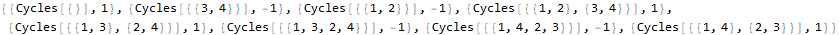

In [238]:
MakePermGroup[GS]

In [239]:
GStoString[GenSet @@ %]

-abdc-bacd+badc+cdab-cdba-dcab+dcba

### 2.11 GetSymmetry, SetSymmetry

정의된 텐서의 대칭을 돌려주거나 설정한다. 인자는 텐서의 이름이다.

In [240]:
Tdefine[T, "abc"]; GetSymmetry[T]

GenSet[]

In [241]:
TMP`defineOperand[T, "T", "abc", {Latin}, {-1}]; GetSymmetry[T]

GenSet[]

In [242]:
SetSymmetry[T, "acb"]; GetSymmetry[T]

GenSet[{Cycles[{{2, 3}}], 1}]

In [243]:
Tdefine[Eps, "*"]; GetSymmetry[Eps]

Nonsymmetric

In [244]:
TMP`defineOperand[Eps, "Eps", "*", {Latin}, {-1}];
GetSymmetry[Eps]

Nonsymmetric

In [246]:
SetSymmetry[Eps, "*-"]; GetSymmetry[Eps]

Antisymmetric

In [247]:
SetSymmetry[Eps, "*+"]; GetSymmetry[Eps]

Symmetric

### 2.12 getGenSetOf

정의된 텐서의 대칭을 입력된 인덱스를 기준으로 생성하여 돌려 준다:

GenSet[]
GenSet[{Cycles[{{1, 2}}], 1}]
GenSet[{Cycles[{{1, 2}}], 1}]
GenSet[{Cycles[{{1, 2}, {3, 4}}], 1}]
GenSet[{Cycles[{{1, 2}, {3, 4}}], 1}]
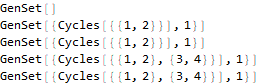

In [250]:
Tdefine[T, "badc"];
TMP`getGenSetOf /@ {T[la], T[la, lb], T[la, lb, lc],
                     T[la, lb, lc, ld],
                     T[la, lb, lc, ld, le]} // ColumnForm

GenSet[]
GenSet[{Cycles[{{1, 2}}], 1}]
GenSet[{Cycles[{{1, 2}}], 1}, {Cycles[{{2, 3}}], 1}]
GenSet[{Cycles[{{1, 2}}], 1}, {Cycles[{{2, 3}}], 1}, {Cycles[{{3, 4}}], 1}]
GenSet[{Cycles[{{1, 2}}], 1}, {Cycles[{{2, 3}}], 1}, {Cycles[{{3, 4}}], 1}]
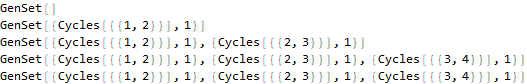

In [252]:
Tdefine[T, "4+"];
TMP`getGenSetOf /@ {T[la], T[la, lb], T[la, lb, lc],
                     T[la, lb, lc, ld],
                     T[la, lb, lc, ld, le]} // ColumnForm

임의 rank 텐서에 대하여:

GenSet[]
GenSet[{Cycles[{{1, 2}}], 1}]
GenSet[{Cycles[{{1, 2}}], 1}, {Cycles[{{2, 3}}], 1}]
GenSet[{Cycles[{{1, 2}}], 1}, {Cycles[{{2, 3}}], 1}, {Cycles[{{3, 4}}], 1}]
GenSet[{Cycles[{{1, 2}}], 1}, {Cycles[{{2, 3}}], 1}, {Cycles[{{3, 4}}], 1}, 
 
>   {Cycles[{{4, 5}}], 1}]
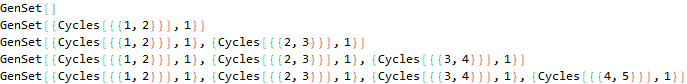

In [254]:
Tdefine[T, "*+"];
TMP`getGenSetOf /@ {T[la], T[la, lb], T[la, lb, lc],
                     T[la, lb, lc, ld],
                     T[la, lb, lc, ld, le]} // ColumnForm

GenSet[]
GenSet[]
GenSet[]
GenSet[]
GenSet[]
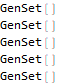

In [256]:
Tdefine[T, "*"]; 
TMP`getGenSetOf /@ {T[la], T[la, lb], T[la, lb, lc],
                     T[la, lb, lc, ld],
                     T[la, lb, lc, ld, le]} // ColumnForm

## 3. Operators

In [258]:
Tdefine[f[]]; Tdefine[T, "ba"]; Tdefine[V, "\[Xi]", "a"]

### 3.1 defineOperator

새로운 연산자를 정의한다. 이 함수는 연산자의 출력 모양만을 결정함을 주의하라. 실제 각각의 연산자가 `IndexecObject`에 작용하는 역할은 따로이 정의해야 한다. 인자로는 연산자의 이름, 출력을 위한 문자열, 연산자 Type, 옵션으로 그 연산자가 속할 Kind가  있다. 연산자 Type은 `CD`, `LD`, `XD`, `XP`가 있다.

#### 3.1.1 CD Type Operator

Covariant Derivative 형태의 연산자이다. 연산자의 인자로 하나의 인덱스와 operand가 있는 경우이다.

In [259]:
TMP`defineOperator[CovD, "\[Del]", CD]

In [260]:
{CovD[-1, T[ua, ub]], CovD[1, T[ua, ub]], CovD[la, T[ua, ub]], 
 CovD[ua, T[la, ub]], CovD[ua, nonT[ub, uc]]}

{CovD[-1, T[ua, ub]], CovD[1, T[ua, ub]], CovD[la, T[ua, ub]], CovD[ua, T[la, ub]], 
 
>   CovD[ua, nonT[ub, uc]]}

In [261]:
TMP`defineOperator[OD, "\[PartialD]", CD];

In [262]:
{OD[-1, T[ua, ub]], OD[1, T[ua, ub]], OD[l\[Mu], T[ua, ub]], 
 OD[la, T[ua, ub]], OD[la, nonT[ua, ub]]}

{OD[-1, T[ua, ub]], OD[1, T[ua, ub]], OD[lμ, T[ua, ub]], OD[la, T[ua, ub]], 
 
>   OD[la, nonT[ua, ub]]}

Kind를 지정할 수 있다.

In [263]:
TMP`defineOperator[BasisD, "D", CD, Latin]

In [264]:
{BasisD[-1, T[ua, ub]], BasisD[1, T[ua, ub]],
 BasisD[lA, T[ua, ub]], BasisD[la, T[ua, ub]],
 BasisD[la, nonT[ua, ub]]}

{BasisD[-1, T[ua, ub]], BasisD[1, T[ua, ub]], BasisD[lA, T[ua, ub]], 
 
>   BasisD[la, T[ua, ub]], BasisD[la, nonT[ua, ub]]}

In [265]:
TMP`defineOperator[CovD, "D", CD, Capital];
TMP`defineOperand[T, "T", "ab", {Capital}, {-1}]

In [267]:
CovD[lA, T[uB, uC]]

CovD[lA, T[uB, uC]]

In [268]:
TMP`defineOperand[T, "T", "ab", {Latin}, {-1}]

#### 3.1.2 LD Type Operator

Lie Derivative 형태의 연산자이다. 연산자의 인자로 하나의 Symbol과 operand가 있는 경우이다.

In [269]:
TMP`defineOperator[LieD, "\[ScriptCapitalL]", LD]

In [270]:
{LieD[nonV, T[ua, ub]], LieD[nonV, nonT[ua, ub]]}

{LieD[nonV, T[ua, ub]], LieD[nonV, nonT[ua, ub]]}

In [271]:
LieD[V, T[ua, ub]]

LieD[V, T[ua, ub]]

#### 3.1.3 XD Type Operator

Exterior Derivative 형태의 연산자이다. 연산자의 인자로 operand만 있는 경우이다.

In [272]:
TMP`defineOperator[BOX, "\[Square]", XD]

In [273]:
{BOX[T[ua, ub]], BOX[nonT[ua, ub]]}

{BOX[T[ua, ub]], BOX[nonT[ua, ub]]}

In [274]:
TMP`defineOperator[Lap,
  "\!\(\*SuperscriptBox[\(\[PartialD]\), \(2\)]\)", XD]

In [275]:
Lap[T[ua, ub]]

Lap[T[ua, ub]]

#### 3.1.4 XP Type Operator

Exterior Product 형태의 연산자이다. 연산자의 인자로 여러 개의 operand가 있는 경우이다. 이 경우는 실제 출력의 형태를 지정하기 위해 MakeBoxes 함수를 정의하여야 한다.

In [276]:
TMP`defineOperator[ExtP, "\[Wedge]", XP]

In [277]:
ExtP[T[ua, ub], nonT[ua, ub]]

ExtP[T[ua, ub], nonT[ua, ub]]

In [278]:
ExtP /: MakeBoxes[ExtP[args__], StandardForm]
    := MakeBoxes[Wedge[args]]

In [279]:
ExtP[T[ua, ub], nonT[ua, ub]]

ExtP[T[ua, ub], nonT[ua, ub]]

### 3.2 IndexedOperatorQ

인자로 주어진 이름이 `defineOperator`로 정의된 것인가를 판단하는 질의함수이다.

In [280]:
{IndexedOperatorQ[CovD], IndexedOperatorQ[Lap]}

{True, True}

### 3.3 get*

In [281]:
TMP`defineOperator[CovD, "\[Del]", CD]

In [282]:
Through[{TMP`getType, TMP`getPrtStr, TMP`getKindL}[CovD]]

{CD, ∇, {Latin}}

### 3.4 KindOf

In [283]:
{KindOf[CovD[la, T[lb, lc]], la],
 KindOf[CovD[la, T[lb, lc]], lb]}

{Latin, Latin}

In [284]:
KindOf[CovD, any]

Latin

In [285]:
KindOf[CovD]

Latin

In [286]:
TMP`defineOperator[LieD, "\[ScriptCapitalL]", LD];
Tdefine[V[la], "a"]

In [288]:
{KindOf[LieD[V, T[la, lb]], any], KindOf[LieD, V]}

{Latin, Latin}

In [289]:
Tdefine[V[l\[Mu]], "a"]

In [290]:
{KindOf[LieD[V, T[la, lb]], any], KindOf[LieD, V]}

{Greek, Greek}

In [291]:
{KindOf[BD[la, F[l\[Mu], l\[Nu], ua]], la], 
 KindOf[BD[la, F[l\[Mu], l\[Nu], ua]], l\[Mu]]}

{Latin, Greek}

In [292]:
{KindOf[BD, la], KindOf[BD, non]}

{Latin, All}

## 4. Scalar Functions

In [293]:
Tdefine[f[]]; Tdefine[T, "ba"]

### 4.1 ScalarFunctionQ

In [294]:
ScalarFunctionQ /@ {Tscalar, Power, Log, Sin, Cos, Tanh, someF}

{True, True, True, True, True, True, False}

### 4.2 Wrapper of Scalars: `Tscalar`

Scalar 표현의 `Head`를 위한 것이다.

In [295]:
expr = {Sinh[f[]], Sinh[Tscalar[f[]]],
         Sinh[Tscalar[T[la, lb] T[ua, ub]]]}

{Sinh[f[]], Sinh[Tscalar[f[]]], Sinh[Tscalar[T[la, lb] T[ua, ub]]]}

In [296]:
expr // FullForm

List[Sinh[f[]], Sinh[Tscalar[f[]]], Sinh[Tscalar[Times[T[la, lb], T[ua, ub]]]]]

상수 심볼과 Scalar 함수는 자동적으로 조정된다:

In [297]:
{Tscalar[a Sin[f[]] Log[f[]]], Tscalar[c f[]], Tscalar[c]}

{a Log[f[]] Sin[f[]], c Tscalar[f[]], c}

In [298]:
% // FullForm

List[Times[a, Log[f[]], Sin[f[]]], Times[c, Tscalar[f[]]], c]

중첩된 `Tscalar`는 자동적으로 재조정된다:

In [299]:
Tscalar[Sinh[x] T[la, lb] T[ua, ub]
         Tscalar[T[la, ub] T[ua, lb]] a Tscalar[f[]]]

a Sinh[x] Tscalar[f[]] Tscalar[T[la, ub] T[ua, lb]] Tscalar[T[la, lb] T[ua, ub]]

In [300]:
% // FullForm

Times[a, Sinh[x], Tscalar[f[]], Tscalar[Times[T[la, ub], T[ua, lb]]], 
 
>   Tscalar[Times[T[la, lb], T[ua, ub]]]]

In [301]:
Tscalar[Tscalar[T[la, lb] T[ua, ub]]]

Tscalar[T[la, lb] T[ua, ub]]

In [302]:
% // FullForm

Tscalar[Times[T[la, lb], T[ua, ub]]]

스칼라 표현의 Log:

In [303]:
Log@Tscalar[a f[] T[la] T[ua]]

Log[a Tscalar[f[] T[la] T[ua]]]

In [304]:
% // FullForm

Log[Times[a, Tscalar[Times[f[], T[la], T[ua]]]]]

스칼라 표현의 Power:

In [305]:
Tscalar[a T[la] T[ua]]^2

2                     2
a  Tscalar[T[la] T[ua]]

In [306]:
% // FullForm

Times[Power[a, 2], Power[Tscalar[Times[T[la], T[ua]]], 2]]

In [307]:
expr = {Tscalar[T[la] T[ua]]^2, Tscalar[Tscalar[T[la] T[ua]]^2]}

2                      2
{Tscalar[T[la] T[ua]] , Tscalar[T[la] T[ua]] }

인덱스를 갖는 텐서에 Power 연산을 하려면 먼저 Tscalar로 둘러 싸야 한다:

In [308]:
{(T[la, lb] T[ua, ub])^2, Tscalar[T[la, lb] T[ua, ub]]^2}

2          2                              2
{T[la, lb]  T[ua, ub] , Tscalar[T[la, lb] T[ua, ub]] }

### 4.3 Wrapper for Invalid Expressions: `ErrorT`

In [309]:
Through[{ObjectQ, ScalarFunctionQ}@ErrorT]

{False, False}

In [310]:
ErrorT[A]

ErrorT[A]

In [312]:
Tdefine[T[la], "ab"]

In [313]:
{T[lA, lb], T[la, ub]}

{T[lA, lb], T[la, ub]}

In [314]:
% // SyntaxCheck

`1` is not a valid `2`.: lA is not a valid index.

{ErrorT[T][lA, lb], T[la, ub]}

In [315]:
% // FullForm

List[ErrorT[T][lA, lb], T[la, ub]]